In [2]:
!pip freeze > local_env.txt

In [1]:
import os
import numpy as np
import torch
from transformers import AutoTokenizer, Gemma3ForCausalLM
from datasets import load_from_disk

import threading
from torch.utils.tensorboard import SummaryWriter
from torch.cuda.amp import autocast, GradScaler



/usr/local/lib/python3.10/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/usr/local/lib/python3.10/dist-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


[2025-05-25 11:55:25,106] [INFO] [real_accelerator.py:222:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/usr/bin/ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


In [2]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
torch.autograd.set_detect_anomaly(True)

TOI = np.fromfile("gemma3_TOI", dtype=np.int32)

model = Gemma3ForCausalLM.from_pretrained("google/gemma-3-1b-pt", trust_remote_code=True, cache_dir="/nvmes/A4", device_map='cuda:0')  
teacher = Gemma3ForCausalLM.from_pretrained("google/gemma-3-4b-pt", trust_remote_code=True, cache_dir="/nvmes/A4", device_map='cuda:1')  
tokenizer = AutoTokenizer.from_pretrained("google/gemma-3-1b-pt", trust_remote_code=True, cache_dir="/nvmes/A4", )
ds = load_from_disk("/home/igli/.cache/huggingface/datasets/filtered-math")
loader = torch.utils.data.DataLoader(ds, batch_size=1, shuffle=False)

scaler = GradScaler()

VOCABSIZE = model.lm_head.out_features

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/48 [00:00<?, ?it/s]

In [3]:
class InflatedDecoder(torch.nn.Module):
    def __init__(self,old_decoder, counts, mode='fresh', noise_init_fn = None):
        super().__init__()
        with torch.no_grad():
            if noise_init_fn:
                noise = noise_init_fn(torch.empty(counts.sum().item(), old_decoder.weight.data.size(1))).to('cuda:2')*0.2
            if mode == "centered":
                data = torch.repeat_interleave(old_decoder.weight.data, counts.to('cuda:0'), dim=0).to(device='cuda:2', dtype=torch.float32)
            if mode == "fresh":
                data = torch.empty((counts.sum().item(), old_decoder.weight.data.size(1)), dtype=torch.float32)
                torch.nn.init.kaiming_uniform_(data, a=torch.math.sqrt(5))
            if mode == "noise":
                data = torch.empty((counts.sum().item(), old_decoder.weight.data.size(1)), dtype=torch.float32)
                torch.nn.init.zeros_(data)
            if noise_init_fn:
                data += noise
        self.weights = torch.nn.Parameter(data)
        # self.bias = torch.Parameter(torch.empty_like(old_decoder.bias))
        # self.bias.data[:] = old_decoder.bias.data[:]
        self.bias = None #old_decoder.bias
    def forward(self, x):
        x = x.to(dtype=torch.float32, device=self.weights.device).contiguous()
        print(f"x:{x.dtype}, {x.device}")
        print(f"self.weights:{self.weights.dtype}, {self.weights.device}")
        print(f"self.bias:{self.bias}")
        return torch.nn.functional.linear(x, self.weights, self.bias)

def loss_fn(input_dist, target_dist):
    ## TODO: Implement the loss fn
    # In our old implementation we were computing this in the forward.
    # Do we want to do this similarly here?
    input_dist = torch.clamp(input_dist, min=1e-12)
    target_dist = torch.clamp(target_dist, min=1e-12)
    print("Loss inputs - student:", input_dist.min(), input_dist.max(), input_dist.isnan().any())
    print("Loss inputs - teacher:", target_dist.min(), target_dist.max(), target_dist.isnan().any())
    print("Sum student:", input_dist.sum(dim=-1).mean())
    print("Sum teacher:", target_dist.sum(dim=-1).mean())
    with autocast(dtype=torch.float32):
        target_dist = target_dist.to(input_dist.device)
        print("[DEBUG] input_dist.device:", input_dist.device)
        print("[DEBUG] target_dist.device:", target_dist.device)
        return torch.nn.functional.kl_div(input_dist[...,:tokenizer.vocab_size], target_dist[...,:tokenizer.vocab_size])

def get_teacher_distribution(model, input_ids, attention_mask):
    with torch.no_grad():
        out = model.forward(input_ids, attention_mask, return_dict=True, use_cache=False, output_hidden_states=False)
        return out['logits'].softmax(dim=-1)

def get_student_distribution(student_model, inflated_decoder, cummulative_neuron_counts, input_ids, attention_mask):
    with torch.no_grad():
        backbone_out = student_model.model(input_ids, attention_mask, return_dict=True,use_cache=False)
        torch.cuda.synchronize(device=backbone_out.last_hidden_state.device)

    print("[DEBUG] backbone_out.last_hidden_state.device:", backbone_out.last_hidden_state.device)    
    
    with autocast(dtype=torch.float32):
        with torch.cuda.device('cuda:2'):
            inflated_input = backbone_out.last_hidden_state.to(dtype=torch.float32, device=inflated_decoder.weights.device).contiguous()
            try:
                inflated_logits = inflated_decoder(inflated_input)
            except RuntimeError as e:
                print("[EXCEPTION in InflatedDecoder]", e)
                raise
            # inflated_logits = inflated_decoder(inflated_input)
            # torch.cuda.synchronize('cuda:2')
            torch.cuda.set_device('cuda:2')
            torch.cuda.synchronize()

        print("[DEBUG] inflated_input.device:", inflated_input.device)

        # inflated_logits = inflated_decoder(inflated_input)
        print("[DEBUG] inflated_logits.device:", inflated_logits.device)

        with torch.no_grad():
            stabilizers = inflated_logits.max(dim=-1, keepdims=True).values.detach()
        inflated_logits = inflated_logits - stabilizers
        accummulated_logits = torch.exp(inflated_logits).cumsum(dim=-1)
        # cumsum is inclusive of the ends, we need to exclude, so pad by 0 in the beginning to mimic the empty sum
        assert cummulative_neuron_counts[0] == 0
        assert cummulative_neuron_counts[-1] == accummulated_logits.shape[-1] # safe access after padding
        accummulated_logits = torch.nn.functional.pad(accummulated_logits, (1,0), mode='constant', value=0)
    
        ### APPARENTLY EMPTY DOES NOT ENABLE GRADS BY DEFAULT
        # distribution = torch.empty((backbone_out.last_hidden_state.size(0), backbone_out.last_hidden_state.size(1),VOCABSIZE), requires_grad=True)
        distribution = accummulated_logits[..., cummulative_neuron_counts[1:]] - accummulated_logits[..., cummulative_neuron_counts[:-1]]
        distribution = distribution / accummulated_logits[..., -1:]
        
        print("[DEBUG] distribution.device:", distribution.device)

        del accummulated_logits, stabilizers
        torch.cuda.empty_cache()
        return backbone_out.last_hidden_state, distribution

def learn_one_step(student_model, optimizer, distributions, inflated_decoder, cummulative_neuron_counts,input_ids,attention_mask, student_forward_results, teacher_dist):
    # if distributions == None or len(distributions)==0: return
    # teacher_dist = distributions.pop(0)
    optimizer.zero_grad()
    with autocast(dtype=torch.float32):
        hidden_states, student_distribution = get_student_distribution(student_model, inflated_decoder, cummulative_neuron_counts, input_ids, attention_mask)
        # print("Got student dist and hidden states")
        # print("Computing loss...")
        # print(student_distribution.shape, teacher_dist.shape)
        loss = loss_fn(student_distribution, teacher_dist)
    loss.backward()
    torch.nn.utils.clip_grad_value_(inflated_decoder.parameters(), clip_value=1e-5)
    optimizer.step()
    # scaler.scale(loss).backward()
    # scaler.step(optimizer)
    # scaler.update()

    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    student_forward_results.append((hidden_states, loss.item()))
    # print("Optimizer stepping...")
    # assert len(distributions) == 0

def teacher_prepare(model, input_ids, attention_mask):
    return get_teacher_distribution(model, input_ids.to(model.device), attention_mask.to(model.device))

def teacher_loop(dataloader, configuration):
    teacher_model = configuration['teacher_model']
    for i,batch in enumerate(dataloader):
        with condition:
            while shared_list:
                condition.wait()
            print("Teacher Loop : Shared list length =", len(shared_list))
            lines = batch['text']
            batch = tokenizer(lines, max_length=512, padding=True, truncation=True, return_tensors="pt")
            input_ids = batch['input_ids']
            attention_mask = batch['attention_mask']
            # print("Starting teacher_prepare...")
            # print("Returned from teacher_prepare...")
            teacher_dist = teacher_prepare(teacher_model, input_ids, attention_mask)
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
            # print("Obtained lock; pushing to shared list")
            shared_list.append((teacher_dist, input_ids, attention_mask, i))
            # print("Notifying")
            condition.notify()
    with condition:
        shared_list.append(None)
        condition.notify()

def student_loop(configuration):
    writer = SummaryWriter(f"{configuration['log_path']}/{configuration['experiment_name']}")
    student_model = configuration['student_model']
    cum_neurons = torch.nn.functional.pad(torch.cumsum(configuration['neuron_counts'], dim=-1), (1,0), mode='constant', value=0)
    inflated_decoder = InflatedDecoder(student_model.lm_head, configuration['neuron_counts'], mode="centered", noise_init_fn=configuration['noise_init_fn']).to('cuda:2')
    # print("Finished inflating")
    optimizer = configuration['optimizer'](inflated_decoder.parameters())

    while True:
        with condition:
            while not shared_list:
                condition.wait()
            print("Student Loop : Shared list length =", len(shared_list))
            # print("Poppoing results out")
            data = shared_list.pop(0)

            if data is None:
                break
            teacher_dist, input_ids, attention_masks, i = data
            condition.notify()
        # print("Running student forward")
        student_results = []
        learn_one_step(student_model, optimizer, (None), inflated_decoder, cum_neurons, input_ids.to(student_model.device), attention_masks.to(student_model.device), student_results, teacher_dist)
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        if i % configuration['log_step'] == 0:
            # print("Logging...")
            student_results = student_results.pop(0)
            original_distributions = student_model.lm_head(student_results[0]).softmax(dim=-1).detach()
            # print("inside logging: devices ->", original_distributions.device, teacher_dist.device)
            original_loss = loss_fn(original_distributions, teacher_dist)
            inflated_decoder_loss = student_results[1]

            writer.add_scalar('original loss', original_loss, i)
            writer.add_scalar('improvement', original_loss - inflated_decoder_loss, i)
        del teacher_dist, input_ids, attention_masks, student_results
        torch.cuda.empty_cache()
        
# def train_loop(dataloader, configuration):
#     writer = SummaryWriter(f"{configuration['log_path']}/{configuration['experiment_name']}")
#     student_model, teacher_model = configuration['student'], configuration['teacher']
#     for i, batch in enumerate(dataloader):
#         lines = batch['text']
#         batch = tokenizer(lines, max_length=4000, padding=True, truncation=True, return_tensors="pt")
#         input_ids = batch['input_ids']
#         attention_mask = batch['attention_mask']

#         if i == 0:
#             t1 = threading.Thread(target=teacher_prepare, args=(teacher_model, input_ids, attention_mask, distributions))
#             t1.start()
#             t1.join()
#         t2 = threading.Thread(target=learn_one_step, args=(student_model, optimzier, distributions, inflated_decoder, cum_neurons, input_ids, attention_mask, student_forward_results))
#         t1 = threading.Thread(target=teacher_prepare, args=(teacher_model, input_ids, attention_mask, distributions))
#         t2.start()
#         t1.start()
#         t2.join()
#         t1.join()
#         res = student_forward_results.pop(0)
#         if i % configuration['log_interval'] == 0:
#             with torch.no_grad():
#                 teacher_dist = res[1]
#                 original_distributions = student_model.lm_head(res[0]).softmax(dim=-1).detach()
#                 original_loss = loss_fn(original_distributions, teacher_dist)
#                 inflated_decoder_loss = res[2]

#                 writer.add_scalar('original loss', original_loss, i)
#                 writer.add_scalar('improvement', original_loss - inflated_decoder_loss, i)

condition = threading.Condition()
shared_list = []
def main():
    neuron_counts = torch.ones(VOCABSIZE, dtype=torch.int32)
    neuron_counts[TOI[    : 200]] = 500
    neuron_counts[TOI[ 200:1000]] = 100
    neuron_counts[TOI[1000:5000]] = 50
    configuration = {
        'teacher_model' : teacher,
        'student_model' : model,
        'optimizer' : lambda x : torch.optim.Adam(x, lr=0.001),
        'log_step' : 10,
        'log_path' : 'gcptest',
        'experiment_name' : 'progressive_clustering/noisy_centered_looseClamp',
        'neuron_counts' : neuron_counts,
        'noise_init_fn' : lambda x : torch.nn.init.normal_(x, mean=0, std=0.03)
    }
    t1 = threading.Thread(target=teacher_loop, args=(loader, configuration))
    t2 = threading.Thread(target=student_loop, args=(configuration,))
    t1.start()
    t2.start()
    t1.join()
    t2.join()


In [ ]:
main()

Teacher Loop : Shared list length = 0
Student Loop : Shared list length = 1
Teacher Loop : Shared list length = 0
[DEBUG] backbone_out.last_hidden_state.device: cuda:0
x:torch.float32, cuda:2
self.weights:torch.float32, cuda:2
self.bias:None
[DEBUG] inflated_input.device: cuda:2
[DEBUG] inflated_logits.device: cuda:2
[DEBUG] distribution.device: cuda:2
Loss inputs - student: tensor(1.0000e-12, device='cuda:2', grad_fn=<MinBackward1>) tensor(1.0000, device='cuda:2', grad_fn=<MaxBackward1>) tensor(False, device='cuda:2')
Loss inputs - teacher: tensor(1.0000e-12, device='cuda:1') tensor(0.9989, device='cuda:1') tensor(False, device='cuda:1')
Sum student: tensor(1.0000, device='cuda:2', grad_fn=<MeanBackward0>)
Sum teacher: tensor(1.0000, device='cuda:1')
[DEBUG] input_dist.device: cuda:2
[DEBUG] target_dist.device: cuda:2


/home/igli/.local/lib/python3.10/site-packages/torch/nn/functional.py:2976: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(


Loss inputs - student: tensor(1.0000e-12, device='cuda:0') tensor(1.0000, device='cuda:0') tensor(False, device='cuda:0')
Loss inputs - teacher: tensor(1.0000e-12, device='cuda:1') tensor(0.9989, device='cuda:1') tensor(False, device='cuda:1')
Sum student: tensor(1.0000, device='cuda:0')
Sum teacher: tensor(1.0000, device='cuda:1')
[DEBUG] input_dist.device: cuda:0
[DEBUG] target_dist.device: cuda:0
Student Loop : Shared list length = 1
Teacher Loop : Shared list length = 0
[DEBUG] backbone_out.last_hidden_state.device: cuda:0
x:torch.float32, cuda:2
self.weights:torch.float32, cuda:2
self.bias:None
[DEBUG] inflated_input.device: cuda:2
[DEBUG] inflated_logits.device: cuda:2
[DEBUG] distribution.device: cuda:2
Loss inputs - student: tensor(1.0000e-12, device='cuda:2', grad_fn=<MinBackward1>) tensor(0.9998, device='cuda:2', grad_fn=<MaxBackward1>) tensor(False, device='cuda:2')
Loss inputs - teacher: tensor(1.0000e-12, device='cuda:1') tensor(0.9978, device='cuda:1') tensor(False, devic

In [ ]:
import numpy as np
toi = torch.tensor(np.fromfile('/home/igli/tokens_of_interest', dtype=np.int32))

In [10]:
toi

tensor([235265,    573, 235269,  ...,   1779,   2579, 211545],
       dtype=torch.int32)

In [11]:
g2tokenizer = AutoTokenizer.from_pretrained('google/gemma-2b')

In [37]:
old_tokens = g2tokenizer.convert_ids_to_tokens(toi.unsqueeze(1))

In [42]:
g2tokenizer.vocab['\u2009=\u2009']

44450

In [43]:
toi[7629]

tensor(44450, dtype=torch.int32)

In [75]:
old_tokens[2480]

'mathit'

In [34]:
transformed = tokenizer(g2tokenizer.convert_ids_to_tokens(toi.unsqueeze(1)), return_tensors="pt", max_length=5, truncation=True, padding=True)

In [69]:
(transformed['input_ids'][:, 2] == 2).nonzero()

tensor([[  51],
        [1172],
        [2440],
        [2480],
        [2871],
        [3022],
        [3052],
        [3101],
        [3262],
        [4662],
        [4717],
        [4731],
        [4829],
        [5111],
        [5263],
        [5330],
        [5374],
        [5386],
        [5477],
        [5703],
        [5719],
        [5761],
        [5791],
        [5846],
        [5922],
        [6124],
        [6156],
        [6373],
        [6578],
        [6626],
        [6674],
        [6791],
        [6794],
        [6847],
        [6877],
        [6939],
        [6958],
        [7111],
        [7363],
        [7385],
        [7439],
        [7481],
        [7593],
        [7598],
        [7599],
        [7600],
        [8050],
        [8216],
        [8465],
        [8531],
        [8660],
        [8756],
        [8788],
        [8807],
        [8884],
        [8887],
        [8897],
        [8940],
        [8955],
        [9014],
        [9044],
        [9212],
        

In [76]:
tokenizer.convert_ids_to_tokens(tokenizer('mathit')['input_ids'])

['<bos>', 'math', 'it']

In [97]:
batch = next(iter(loader))

In [96]:
len(batch['text'][0].split())

1372

In [95]:
len(tokenizer(batch['text'][0]).input_ids)

1849

In [99]:
from collections import Counter
token_counter = Counter()
for batch in loader:
    line = batch['text'][0]
    tokens = tokenizer(line).input_ids
    token_counter.update(tokens)

In [100]:
most_common = token_counter.most_common(10000)
IDS = [token_id for token_id, _ in most_common]
import numpy as np
IDS_np = np.array(IDS, dtype=np.int32)
IDS_np.tofile("gemma3_TOI")

In [117]:
(loaded_toi == IDS_np).all()

True

In [109]:
import matplotlib.pyplot as plt

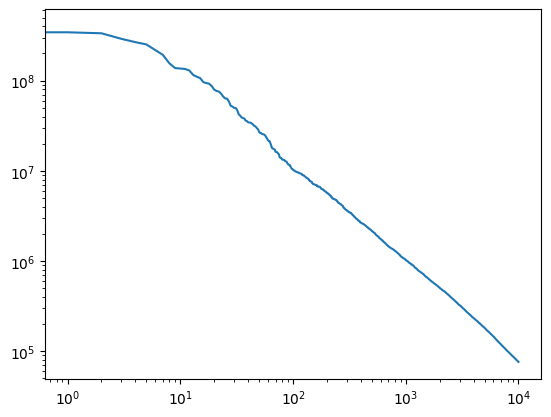

In [111]:
plt.plot(list(map(lambda x : x[1], most_common)))
plt.yscale('log')
plt.xscale('log')

In [112]:
tokenizer.convert_ids_to_tokens(list(map(lambda x : x[0], most_common)))

['.',
 ',',
 '▁the',
 '▁',
 '1',
 '0',
 '2',
 '▁of',
 '\n\n',
 '\n',
 '▁and',
 '▁to',
 '▁a',
 '3',
 '▁is',
 '-',
 '▁in',
 '4',
 '5',
 '▁(',
 ':',
 '6',
 ')',
 '9',
 '7',
 '8',
 '▁that',
 '▁for',
 '_',
 '(',
 '<0xC2>',
 '<0xA0>',
 '▁\\',
 '{',
 '▁with',
 '▁are',
 '▁be',
 '▁=',
 '▁on',
 '▁it',
 '▁I',
 '/',
 '▁as',
 "'",
 's',
 '▁by',
 '▁this',
 '▁The',
 '▁you',
 '$',
 '\\',
 'x',
 '▁can',
 '▁we',
 '▁$',
 '▁at',
 '}',
 '▁an',
 '▁from',
 '▁or',
 '▁not',
 '▁have',
 '▁-',
 't',
 '•',
 '=',
 ';',
 ').',
 '▁which',
 '’',
 '▁+',
 '▁A',
 'n',
 '?',
 ']',
 '▁will',
 '▁one',
 'a',
 '▁if',
 '▁"',
 '▁but',
 '▁was',
 '+',
 '▁all',
 '▁.',
 '^',
 '),',
 'i',
 '▁[',
 '▁x',
 '▁has',
 'A',
 'The',
 'frac',
 '[',
 '_{',
 '▁more',
 '▁two',
 '$$',
 '▁In',
 'm',
 'b',
 '}{',
 '"',
 'e',
 '▁$\\',
 '▁This',
 '▁$$',
 '▁so',
 '▁use',
 '▁time',
 '.,',
 'd',
 '▁number',
 '▁data',
 'f',
 '▁your',
 '▁then',
 '▁there',
 'c',
 '▁using',
 '▁&',
 '▁also',
 '▁{',
 '▁other',
 '▁function',
 '▁some',
 'y',
 '▁than',
 '!',
 '

In [79]:
token_counter.update([1,1,1,2,1,2,2,3])

In [80]:
token_counter

Counter({1: 4, 2: 3, 3: 1})

In [63]:
tokenizer.vocab['▁Asymptote']

KeyError: '▁Asymptote'

In [31]:
transformed['input_ids'][524]

tensor([  2, 432, 398, 432, 398])

In [30]:
g2tokenizer.decode(toi[524])

'\xa0\xa0'

In [ ]:
neuron_counts = torch.ones(VOCABSIZE, dtype=torch.int32) * 2


In [ ]:
cum_neurons = torch.nn.functional.pad(torch.cumsum(neuron_counts, dim=-1), (1,0), mode='constant', value=0)
inflated_decoder = InflatedDecoder(model.lm_head, neuron_counts, mode="fresh").to(model.device)
print("Finished inflating")


In [ ]:
batch = next(iter(loader))

In [ ]:
lines = batch['text']
batch = tokenizer(lines, max_length=10, padding=True, truncation=True, return_tensors="pt")
input_ids = batch['input_ids']
attention_mask = batch['attention_mask']
print("Starting teacher_prepare...")


In [15]:
teacher_dist = teacher_prepare(teacher, input_ids, attention_mask)


In [17]:
shared_list.append(teacher_dist)
shared_list.append(input_ids)
shared_list.append(attention_mask)
shared_list.append(0)

In [18]:
shared_list

[tensor([[[2.1624e-14, 1.4480e-06, 5.7373e-08,  ..., 1.9680e-09,
           1.9515e-09, 1.9787e-09],
          [2.2946e-15, 1.2271e-10, 7.9443e-10,  ..., 8.8418e-11,
           8.7466e-11, 8.7731e-11],
          [1.3529e-12, 2.1126e-06, 1.1830e-08,  ..., 1.6584e-08,
           1.6569e-08, 1.6585e-08],
          ...,
          [2.2040e-13, 5.4931e-04, 3.9612e-08,  ..., 8.9299e-09,
           8.9404e-09, 8.9414e-09],
          [1.3278e-13, 2.2018e-06, 1.9527e-09,  ..., 3.2364e-09,
           3.1807e-09, 3.2610e-09],
          [1.5215e-14, 4.3376e-07, 1.1600e-10,  ..., 2.9696e-09,
           2.9825e-09, 3.0265e-09]],
 
         [[2.1624e-14, 1.4480e-06, 5.7372e-08,  ..., 1.9680e-09,
           1.9515e-09, 1.9787e-09],
          [1.3805e-14, 4.2596e-10, 7.7696e-11,  ..., 3.7305e-10,
           3.7899e-10, 3.8227e-10],
          [6.4191e-15, 5.3011e-09, 3.2910e-12,  ..., 1.8876e-10,
           1.8677e-10, 1.9553e-10],
          ...,
          [9.9482e-16, 1.2131e-06, 3.2604e-10,  ..., 1.528

In [19]:
teacher_dist = shared_list.pop(0)
if teacher_dist is None:
    print('wtf')
input_ids = shared_list.pop(0)
attention_masks = shared_list.pop(0)
i = shared_list.pop(0)

In [22]:
optimizer = torch.optim.Adam(inflated_decoder.parameters())

In [25]:
student_results = []
learn_one_step(model, optimizer, (None), inflated_decoder, cum_neurons, input_ids.to(model.device), attention_masks.to(model.device), student_results, teacher_dist)

Got student dist and hidden states
Computing loss...
torch.Size([4, 10, 262144]) torch.Size([4, 10, 262208])
Optimizer stepping...


/home/igli/.local/lib/python3.10/site-packages/torch/nn/functional.py:2976: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(


In [20]:
teacher.lm_head.weight.shape

torch.Size([262208, 2560])

In [21]:
model.lm_head.weight.shape

torch.Size([262144, 1152])

In [19]:
tokenizer.vocab_size

262144

In [13]:
shared_list

[]

In [ ]:
main()

Teacher Loop : Shared list length = 0
Starting teacher_prepare...
Returned from teacher_prepare...
Obtained lock; pushing to shared list
Notifying
Teacher Loop : Shared list length = 4
Starting teacher_prepare...
Returned from teacher_prepare...
Finished inflating
Student Loop : Shared list length = 4
Poppoing results out
Running student forward
Obtained lock; pushing to shared list
Notifying
Teacher Loop : Shared list length = 4
Starting teacher_prepare...
Got student dist and hidden states
Computing loss...
torch.Size([4, 10, 262144]) torch.Size([4, 10, 262208])
Optimizer stepping...
Logging...


/home/igli/.local/lib/python3.10/site-packages/torch/nn/functional.py:2976: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(


inside logging: devices -> cuda:0 cpu
Student Loop : Shared list length = 4
Poppoing results out
Running student forward
Got student dist and hidden states
Computing loss...
torch.Size([4, 10, 262144]) torch.Size([4, 10, 262208])
Optimizer stepping...
Returned from teacher_prepare...
Obtained lock; pushing to shared list
Notifying
Student Loop : Shared list length = 4
Poppoing results out
Teacher Loop : Shared list length = 3
Running student forward
Starting teacher_prepare...
Got student dist and hidden states
Computing loss...
torch.Size([4, 10, 262144]) torch.Size([4, 10, 262208])
Optimizer stepping...
Returned from teacher_prepare...
Obtained lock; pushing to shared list
Notifying
Student Loop : Shared list length = 4
Poppoing results out
Teacher Loop : Shared list length = 3
Running student forward
Starting teacher_prepare...
Got student dist and hidden states
Computing loss...
torch.Size([4, 10, 262144]) torch.Size([4, 10, 262208])
Optimizer stepping...
Returned from teacher_prep

In [ ]:
sample_inputs = ["The capital of France is Paris, whereas the capital of England is", "1+1+1="]
inputs = tokenizer(sample_inputs, return_tensors="pt", padding=True)

In [7]:
neuron_counts = torch.ones(262208, dtype=torch.int32)
neuron_counts[200:40000] += 5
neuron_counts[40000:200000] += 10
neuron_counts[200000:] += 20
cum_neurons = torch.cumsum(neuron_counts, dim=-1)
cum_neurons = torch.nn.functional.pad(cum_neurons, (1,0), mode='constant', value=0)

In [8]:
inflated_decoder = torch.nn.Linear(model.lm_head.in_features, cum_neurons[-1])

In [10]:
optimizer = torch.optim.AdamW(inflated_decoder.parameters(), betas=(0.9,0.999),lr=0.000001,eps=10e-5)

In [11]:
distributions = []
teacher_prepare(teacher, inputs['input_ids'], inputs['attention_mask'], distributions)

In [12]:
del teacher
torch.cuda.empty_cache()
torch.cuda.synchronize()

import gc
gc.collect()

100

In [13]:
len(distributions)

1

In [14]:
learn_one_step(model, optimizer, distributions, inflated_decoder, cum_neurons, **inputs)

/home/igli/.local/lib/python3.10/site-packages/torch/nn/functional.py:2976: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(


In [10]:
res = get_student_distribution(model, inflated_decoder, cum_neurons, **inputs)

In [11]:
teacher_dist = distributions.pop(0)

In [12]:
res.shape, teacher_dist.shape

(torch.Size([2, 14, 262208]), torch.Size([2, 14, 262208]))

In [13]:
res.requires_grad, teacher_dist.requires_grad

(True, False)

In [14]:
s_embs = model.model(**inputs, return_dict=True,use_cache=False)

In [15]:
s_embs.last_hidden_state.shape

torch.Size([2, 14, 2560])

In [16]:
s_embs.last_hidden_state.requires_grad

True

In [17]:
inf_log = inflated_decoder(s_embs.last_hidden_state)

In [18]:
print(inf_log.requires_grad)

with torch.no_grad():
    stabilizers = inf_log.max(dim=-1, keepdims=True).values.detach()
inf_log = inf_log - stabilizers


print(inf_log.requires_grad)

True
True


In [19]:
accummulated_logits = torch.exp(inf_log).cumsum(dim=-1)
# cumsum is inclusive of the ends, we need to exclude, so pad by 0 in the beginning to mimic the empty sum
assert cum_neurons[0] == 0
assert cum_neurons[-1] == accummulated_logits.shape[-1] # safe access after padding
accummulated_logits = torch.nn.functional.pad(accummulated_logits, (1,0), mode='constant', value=0)

In [20]:
accummulated_logits.requires_grad, accummulated_logits.shape

(True, torch.Size([2, 14, 3305369]))

In [22]:
empty = torch.empty((s_embs.last_hidden_state.size(0), s_embs.last_hidden_state.size(1), VOCABSIZE), requires_grad=True)

In [26]:
empty = accummulated_logits[..., cum_neurons[1:]] - accummulated_logits[..., cum_neurons[:-1]]
empty = empty / accummulated_logits[...,-1:]

In [33]:
loss = loss_fn(empty, teacher_dist)

/home/igli/.local/lib/python3.10/site-packages/torch/nn/functional.py:2976: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(


In [37]:
teacher_dist.shape, empty.shape

(torch.Size([2, 14, 262208]), torch.Size([2, 14, 262208]))

In [39]:
loss.backward()

In [ ]:
optimizer.step()

In [27]:
empty.shape

torch.Size([2, 14, 262208])

In [23]:
empty.requires_grad

True

In [25]:
student_distribution = get_student_distribution(model, inflated_decoder, cum_neurons, **inputs)

In [26]:
student_distribution.requires_grad

True

In [ ]:
backbone_out = model.model(**inputs, return_dict=True,use_cache=False)

In [ ]:
inflated_logits = inflated_decoder(backbone_out.last_hidden_state)

In [ ]:
with torch.no_grad():
    stabilizers = inflated_logits.max(dim=-1, keepdims=True).values
    inflated_logits = inflated_logits - stabilizers
accummulated_logits = torch.exp(inflated_logits).cumsum(dim=-1)
# cumsum is inclusive of the ends, we need to exclude, so pad by 0 in the beginning to mimic the empty sum
assert cum_neurons[0] == 0
assert cum_neurons[-1] == accummulated_logits.shape[-1] # safe access after padding
accummulated_logits = torch.nn.functional.pad(accummulated_logits, (1,0), mode='constant', value=0)
distribution = torch.empty(VOCABSIZE)
distribution = accummulated_logits[cummulative_neuron_counts[1:]] - accummulated_logits[cummulative_neuron_counts[:-1]]
distribution = distribution / distribution.sum(dim=-1, keepdims=True)

In [89]:
import torch

In [93]:
em = torch.empty(10)

In [95]:
em

tensor([ 4.7176e-10,  4.0632e-41, -2.6936e+31,  3.3330e-41,  2.8026e-45,
         0.0000e+00,  0.0000e+00,  0.0000e+00,         nan,  1.5089e-36])

In [92]:
torch.cumsum(torch.arange(1,6), dim=-1)

tensor([ 1,  3,  6, 10, 15])

In [86]:
student_backbone_out = model.model(**input_ids, use_cache=False, return_dict=True, output_hidden_states=False)
student_backbone_out_prime = model.model(**input_ids, use_cache=False, return_dict=True, output_hidden_states=False)

In [87]:
student_backbone_out_prime

BaseModelOutputWithPast(last_hidden_state=tensor([[[-1.6564e-01,  2.7410e-01, -3.3523e-02,  ..., -3.1397e-03,
           2.5436e-01, -1.0479e-01],
         [ 3.0746e-02,  4.1534e-01, -4.8197e-01,  ..., -3.8212e-01,
          -1.2131e+00,  2.6396e+00],
         [-1.6240e+00,  2.7359e+00, -1.3358e-01,  ..., -1.0538e+00,
           4.1861e-02, -3.2043e+00],
         ...,
         [ 5.1800e-01, -7.5635e-01, -1.3415e+00,  ...,  9.0405e-01,
          -3.8500e-01, -1.3088e+00],
         [ 2.3415e+00,  1.4601e+00, -6.9513e-01,  ..., -6.1744e-01,
           1.5046e+00, -4.2933e-01],
         [ 8.5816e-01, -6.1687e-01, -3.1637e-01,  ...,  5.4637e-01,
           4.1631e-01,  1.4273e-01]]], grad_fn=<MulBackward0>), past_key_values=None, hidden_states=None, attentions=None)

In [88]:
student_backbone_out

BaseModelOutputWithPast(last_hidden_state=tensor([[[-1.6564e-01,  2.7410e-01, -3.3523e-02,  ..., -3.1397e-03,
           2.5436e-01, -1.0479e-01],
         [ 3.0746e-02,  4.1534e-01, -4.8197e-01,  ..., -3.8212e-01,
          -1.2131e+00,  2.6396e+00],
         [-1.6240e+00,  2.7359e+00, -1.3358e-01,  ..., -1.0538e+00,
           4.1861e-02, -3.2043e+00],
         ...,
         [ 5.1800e-01, -7.5635e-01, -1.3415e+00,  ...,  9.0405e-01,
          -3.8500e-01, -1.3088e+00],
         [ 2.3415e+00,  1.4601e+00, -6.9513e-01,  ..., -6.1744e-01,
           1.5046e+00, -4.2933e-01],
         [ 8.5816e-01, -6.1687e-01, -3.1637e-01,  ...,  5.4637e-01,
           4.1631e-01,  1.4273e-01]]], grad_fn=<MulBackward0>), past_key_values=None, hidden_states=None, attentions=None)

In [ ]:
class DistillTrainer():
    def __init__(self, backbone, teacher, tok_nref_map):
        with torch.no_grad():
            self.backbone = backbone
            self.teacher = teacher
        
        # New inflated LM-Head
        self.tok_refiners = {
            t : ParallelTrainer(t, clusters, device='cpu', W=None)
            for t, clusters in tok_nref_map.items()
        }
    def teacher_logits(self, input_ids):
        

In [58]:
input_ids['input_ids']

tensor([[     2,    818,   5279,    529,   7001,    563,   9079, 236764,  12176,
            506,   5279,    529,   7591,    563]])

In [59]:
model(input_ids['input_ids']).logits[:,-1].argmax(dim=-1)

tensor([5860])

In [61]:
out = model.forward(**input_ids, return_dict=True)

In [62]:
out

CausalLMOutputWithPast(loss=None, logits=tensor([[[-1.1430e+01,  6.5897e+00,  3.3613e+00,  ..., -1.1258e-02,
          -1.9706e-02, -5.8187e-03],
         [-1.1770e+01,  4.6665e+00, -2.6233e+00,  ...,  3.3895e-02,
           3.3247e-02,  3.2406e-02],
         [-1.0778e+01,  2.9853e+00, -8.3786e-01,  ..., -1.6621e-02,
          -7.2540e-03, -1.5194e-02],
         ...,
         [-1.0008e+01,  5.6794e+00, -1.1733e+00,  ..., -3.4779e-02,
          -1.7272e-02, -2.4468e-02],
         [-1.1506e+01,  8.3976e+00, -2.9757e-01,  ..., -4.3971e-02,
          -3.7438e-02, -4.6352e-02],
         [-1.1032e+01,  8.5592e+00, -6.6009e-01,  ..., -4.6261e-02,
          -3.4588e-02, -4.7280e-02]]], grad_fn=<UnsafeViewBackward0>), past_key_values=<transformers.cache_utils.HybridCache object at 0x71427cfa10f0>, hidden_states=None, attentions=None)

In [69]:
input_ids['input_ids']

tensor([[     2,    818,   5279,    529,   7001,    563,   9079, 236764,  12176,
            506,   5279,    529,   7591,    563]])

In [71]:
preds

'<h1>  of the, a, and the capital of the is London'

In [74]:
preds

['<h1>',
 ' ',
 ' of',
 ' the',
 ',',
 ' a',
 ',',
 ' and',
 ' the',
 ' capital',
 ' of',
 ' the',
 ' is',
 ' London']

In [73]:
preds = tokenizer.batch_decode(out.logits.argmax(dim=-1)[0])
for i in range(14):
    print(tokenizer.decode(input_ids['input_ids'][0,:i+1]) + preds[i])

<bos><h1>
<bos>The 
<bos>The capital of
<bos>The capital of the
<bos>The capital of France,
<bos>The capital of France is a
<bos>The capital of France is Paris,
<bos>The capital of France is Paris, and
<bos>The capital of France is Paris, whereas the
<bos>The capital of France is Paris, whereas the capital
<bos>The capital of France is Paris, whereas the capital of
<bos>The capital of France is Paris, whereas the capital of the
<bos>The capital of France is Paris, whereas the capital of England is
<bos>The capital of France is Paris, whereas the capital of England is London


In [60]:
tokenizer.decode(model.generate(**input_ids, max_new_tokens=10)[0])

'<bos>The capital of France is Paris, whereas the capital of England is London.\n1-2-3-4'

In [45]:
model.lm_head.weight.shape

torch.Size([262208, 2560])